In [219]:
# CELL 1 — Verify all libraries are available
import sys
print(f"Python version: {sys.version}")

libraries = ["pandas", "numpy", "matplotlib", "seaborn", "sklearn", "joblib"]
for lib in libraries:
    try:
        __import__(lib)
        print(f"  ✅ {lib} is installed")
    except ImportError:
        print(f"  ❌ {lib} is MISSING — run: pip install {lib}")


Python version: 3.13.4 (tags/v3.13.4:8a526ec, Jun  3 2025, 17:46:04) [MSC v.1943 64 bit (AMD64)]
  ✅ pandas is installed
  ✅ numpy is installed
  ✅ matplotlib is installed
  ✅ seaborn is installed
  ✅ sklearn is installed
  ✅ joblib is installed


In [220]:
# CELL 2 — Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [221]:
# CELL 3 — Load the LIGTAS voltage dataset
df = pd.read_csv("ligtas_voltage_dataset.csv")

print("=== DATASET LOADED ===")
print(f"Total rows    : {len(df)}")
print(f"Total columns : {len(df.columns)}")
print(f"Columns       : {list(df.columns)}")
print("\nFirst 10 rows:")
display(df.head(10))

print("\nLast 5 rows:")
display(df.tail(5))

=== DATASET LOADED ===
Total rows    : 10451
Total columns : 8
Columns       : ['voltage_v', 'coverage_area_m2', 'radius_m', 'voltage_class', 'danger_score', 'risk_flag', 'label', 'status']

First 10 rows:


,voltage_v,coverage_area_m2,radius_m,voltage_class,danger_score,risk_flag,label,status
0,0.00,31415.93,100.0000,0,0.0000,SAFE,0,Safe
1,0.01,30796.91,99.0099,0,0.0009,SAFE,0,Safe
2,0.02,30196.01,98.0392,0,0.0018,SAFE,0,Safe
3,0.03,29612.52,97.0874,0,0.0027,SAFE,0,Safe
4,0.04,29045.79,96.1538,0,0.0035,SAFE,0,Safe
5,0.05,28495.17,95.2381,0,0.0044,SAFE,0,Safe
6,0.06,27960.06,94.3396,0,0.0053,SAFE,0,Safe
7,0.07,27439.89,93.4579,0,0.0062,SAFE,0,Safe
8,0.08,26934.09,92.5926,0,0.0071,SAFE,0,Safe
9,0.09,26442.16,91.7431,0,0.0080,SAFE,0,Safe



Last 5 rows:


,voltage_v,coverage_area_m2,radius_m,voltage_class,danger_score,risk_flag,label,status
10446,999.6,0.03,0.0999,4,970.9013,DANGER,2,Dangerous
10447,999.7,0.03,0.0999,4,970.9984,DANGER,2,Dangerous
10448,999.8,0.03,0.0999,4,971.0956,DANGER,2,Dangerous
10449,999.9,0.03,0.0999,4,971.1927,DANGER,2,Dangerous
10450,1000.0,0.03,0.0999,4,971.2898,DANGER,2,Dangerous


In [222]:
# CELL 4 — Apply coverage area formula
# Formula: A = π × r²
# Where r = voltage reading from ZMPT101B sensor

df['radius_r']         = df['voltage_v']
df['coverage_area_m2'] = np.pi * (df['radius_r'] ** 2)

# ── ADD THIS: round to 2 decimal places for cleaner display ──
df['coverage_area_m2'] = df['coverage_area_m2'].round(2)

print("✅ Coverage area calculated using A = π × r²")
print("\nSample results:")
sample_voltages = [0, 10, 20, 29.9, 30.0, 50, 100, 220]
for v in sample_voltages:
    row = df[df['voltage_v'] == v]
    if not row.empty:
        area   = row['coverage_area_m2'].values[0]
        status = row['status'].values[0]
        print(f"  V = {v:>6.1f} V  →  A = {area:>12,.2f} m²  [{status}]")

✅ Coverage area calculated using A = π × r²

Sample results:
  V =    0.0 V  →  A =         0.00 m²  [Safe]
  V =   10.0 V  →  A =       314.16 m²  [Check]
  V =   20.0 V  →  A =     1,256.64 m²  [Check]
  V =   29.9 V  →  A =     2,808.62 m²  [Check]
  V =   30.0 V  →  A =     2,827.43 m²  [Dangerous]
  V =   50.0 V  →  A =     7,853.98 m²  [Dangerous]
  V =  100.0 V  →  A =    31,415.93 m²  [Dangerous]
  V =  220.0 V  →  A =   152,053.08 m²  [Dangerous]


In [223]:
# CELL 5 — Data exploration
print("=== DATASET SUMMARY ===")
display(df.describe())

print("\n=== CLASS DISTRIBUTION ===")
counts = df['status'].value_counts()
print(counts)
print(f"\n  Safe      : {counts.get('Safe', 0):,} rows  (Voltage 0.0V – 29.9V)")
print(f"  Dangerous : {counts.get('Dangerous', 0):,} rows  (Voltage 30.0V – 1000.0V)")

=== DATASET SUMMARY ===


,voltage_v,coverage_area_m2,radius_m,voltage_class,danger_score,label,radius_r
count,10451.000000,1.045100e+04,10451.000000,10451.000000,10451.000000,10451.000000,10451.000000
mean,478.578605,1.002158e+06,2.208855,3.684241,431.411379,1.880394,478.578605
std,299.946787,9.407306e+05,8.771019,0.936143,305.114328,0.448335,299.946787
min,0.000000,0.000000e+00,0.099900,0.000000,0.000000,0.000000,0.000000
25%,216.250000,1.469136e+05,0.135200,4.000000,142.944650,2.000000,216.250000
50%,477.500000,7.163028e+05,0.209000,4.000000,422.182200,2.000000,477.500000
75%,738.750000,1.714529e+06,0.460300,4.000000,698.073950,2.000000,738.750000
max,1000.000000,3.141593e+06,100.000000,4.000000,971.289800,2.000000,1000.000000



=== CLASS DISTRIBUTION ===
status
Dangerous    9701
Safe          500
Check         250
Name: count, dtype: int64

  Safe      : 500 rows  (Voltage 0.0V – 29.9V)
  Dangerous : 9,701 rows  (Voltage 30.0V – 1000.0V)


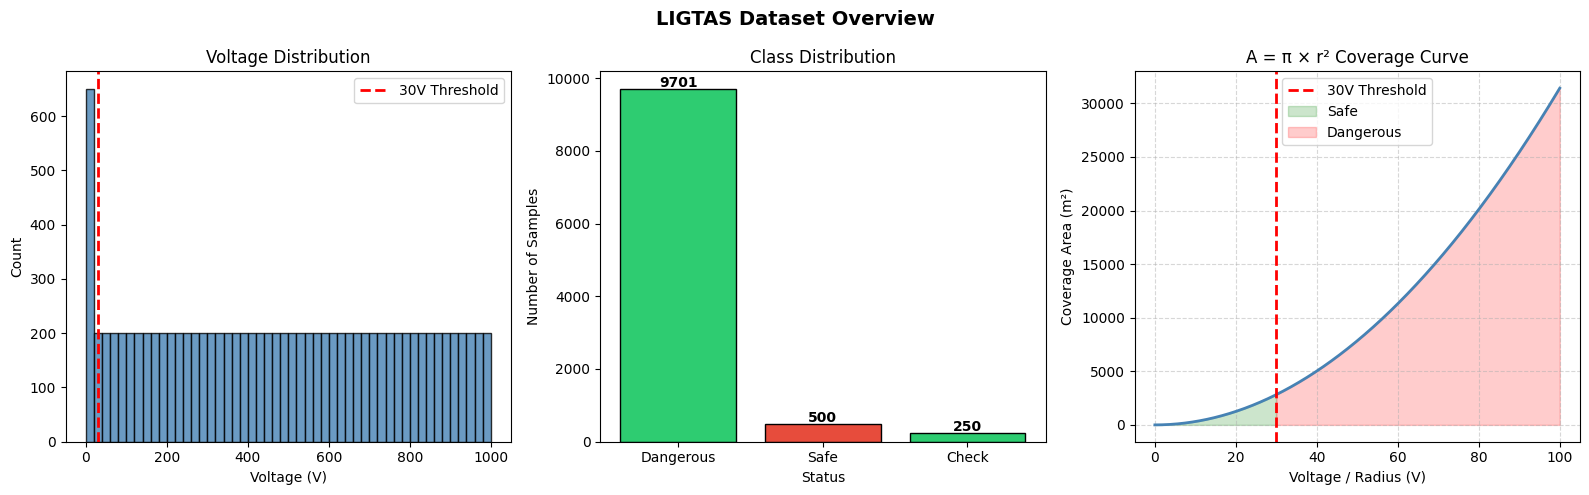

✅ Chart saved as ligtas_overview.png


In [224]:
# CELL 6 — Data visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LIGTAS Dataset Overview', fontsize=14, fontweight='bold')

# --- Plot 1: Voltage Distribution ---
axes[0].hist(df['voltage_v'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=30, color='red', linestyle='--', linewidth=2, label='30V Threshold')
axes[0].set_title('Voltage Distribution')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Class Distribution ---
colors = ['#2ecc71', '#e74c3c']
counts = df['status'].value_counts()
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[1].set_title('Class Distribution')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# --- Plot 3: A = π × r² Curve (0-100V) ---
sample = df[df['voltage_v'] <= 100]
axes[2].plot(sample['voltage_v'], sample['coverage_area_m2'],
             color='steelblue', linewidth=2)
axes[2].axvline(x=30, color='red', linestyle='--', linewidth=2, label='30V Threshold')
axes[2].fill_between(sample['voltage_v'], sample['coverage_area_m2'],
                     where=(sample['voltage_v'] < 30),
                     color='green', alpha=0.2, label='Safe')
axes[2].fill_between(sample['voltage_v'], sample['coverage_area_m2'],
                     where=(sample['voltage_v'] >= 30),
                     color='red', alpha=0.2, label='Dangerous')
axes[2].set_title('A = π × r² Coverage Curve')
axes[2].set_xlabel('Voltage / Radius (V)')
axes[2].set_ylabel('Coverage Area (m²)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ligtas_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as ligtas_overview.png")

In [225]:
# CELL 7 — Prepare features (X) and labels (y)

# Features: voltage + coverage area
X = df[['voltage_v', 'coverage_area_m2']]

# Label: 0 = Safe, 1 = Dangerous
y = df['label']

print("=== FEATURES (X) ===")
display(X.head())

print("\n=== LABELS (y) ===")
print(f"  0 = Safe      : {(y == 0).sum()} samples")
print(f"  1 = Dangerous : {(y == 1).sum()} samples")
print(f"\nTotal : {len(y)} samples")

=== FEATURES (X) ===


,voltage_v,coverage_area_m2
0,0.00,0.00
1,0.01,0.00
2,0.02,0.00
3,0.03,0.00
4,0.04,0.01



=== LABELS (y) ===
  0 = Safe      : 500 samples
  1 = Dangerous : 250 samples

Total : 10451 samples


In [226]:
# CELL 8 — Train/Test split
# 80% for training, 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to testing
    random_state=42,     # fixed seed = same split every time
    stratify=y           # keeps Safe/Dangerous ratio balanced
)

print("=== TRAIN / TEST SPLIT ===")
print(f"  Training samples : {len(X_train):,}  (80%)")
print(f"  Testing  samples : {len(X_test):,}  (20%)")
print(f"\nTraining label distribution:")
print(f"  Safe      : {(y_train == 0).sum()}")
print(f"  Dangerous : {(y_train == 1).sum()}")
print(f"\nTesting label distribution:")
print(f"  Safe      : {(y_test == 0).sum()}")
print(f"  Dangerous : {(y_test == 1).sum()}")

=== TRAIN / TEST SPLIT ===
  Training samples : 8,360  (80%)
  Testing  samples : 2,091  (20%)

Training label distribution:
  Safe      : 400
  Dangerous : 200

Testing label distribution:
  Safe      : 100
  Dangerous : 50


In [227]:
# CELL 9 — Feature scaling using StandardScaler
# This prevents large coverage area values from dominating the model

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train, then transform
X_test_scaled  = scaler.transform(X_test)         # only transform (never fit on test)

print("✅ Features scaled!")
print(f"\nBefore scaling (first row):")
print(f"  {X_train.iloc[0].to_dict()}")
print(f"\nAfter scaling (first row):")
print(f"  voltage_v       : {X_train_scaled[0][0]:.6f}")
print(f"  coverage_area_m2: {X_train_scaled[0][1]:.6f}")

✅ Features scaled!

Before scaling (first row):
  {'voltage_v': 704.2, 'coverage_area_m2': 1557908.38}

After scaling (first row):
  voltage_v       : 0.758737
  coverage_area_m2: 0.598387


In [228]:
# CELL 10 — Train Logistic Regression model
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression training complete!")

Training Logistic Regression...
✅ Logistic Regression training complete!


In [229]:
# CELL 11 — Train Random Forest model
print("Training Random Forest (100 trees)...")

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

print("✅ Random Forest training complete!")

Training Random Forest (100 trees)...
✅ Random Forest training complete!



  MODEL: Logistic Regression
  Accuracy   : 0.9761  (97.61%)
  Precision  : 0.9586
  Recall     : 0.9761
  F1-Score   : 0.9660

Detailed Report:
              precision    recall  f1-score   support

       Check       0.69      1.00      0.82       100
   Dangerous       0.00      0.00      0.00        50
        Safe       1.00      1.00      1.00      1941

    accuracy                           0.98      2091
   macro avg       0.56      0.67      0.61      2091
weighted avg       0.96      0.98      0.97      2091


  MODEL: Random Forest
  Accuracy   : 0.9995  (99.95%)
  Precision  : 0.9995
  Recall     : 0.9995
  F1-Score   : 0.9995

Detailed Report:
              precision    recall  f1-score   support

       Check       0.99      1.00      1.00       100
   Dangerous       1.00      0.98      0.99        50
        Safe       1.00      1.00      1.00      1941

    accuracy                           1.00      2091
   macro avg       1.00      0.99      0.99      2091
weighte

c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

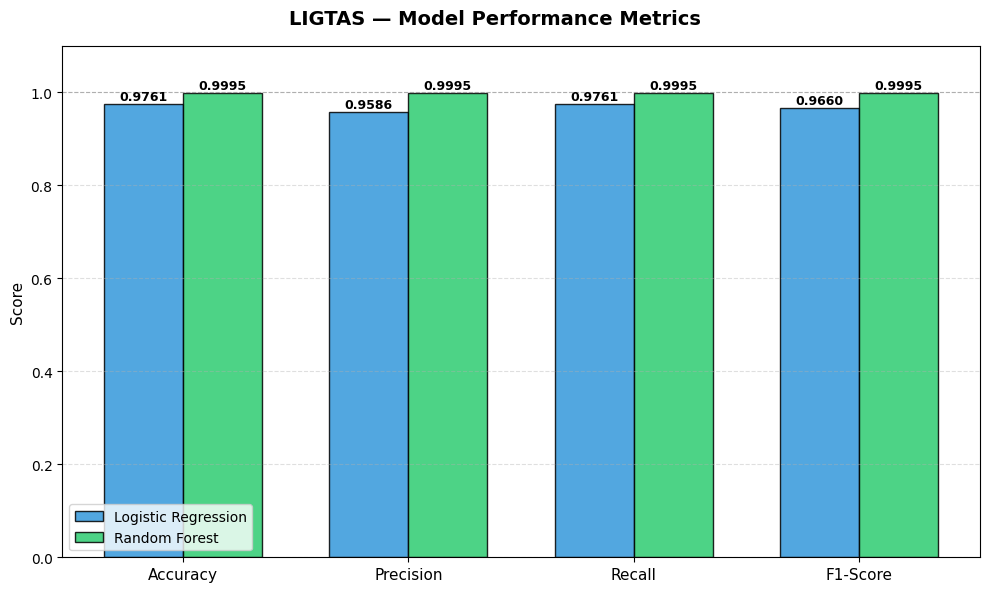

✅ Metrics chart saved as confusion_matrix.png


In [ ]:
# CELL 12 — Evaluate and compare both models

def evaluate_model(name, model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test,    y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test,        y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  MODEL: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"\nDetailed Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Check', 'Dangerous', 'Safe']))
    return acc, prec, rec, f1

# ── Call the function for both models ──
lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model("Logistic Regression", lr_model, X_test_scaled, y_test)
rf_acc, rf_prec, rf_rec, rf_f1 = evaluate_model("Random Forest",        rf_model, X_test_scaled, y_test)

# ── Bar chart: Accuracy, Precision, Recall, F1 ──
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores    = [lr_acc, lr_prec, lr_rec, lr_f1]
rf_scores    = [rf_acc, rf_prec, rf_rec, rf_f1]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('LIGTAS — Model Performance Metrics', fontsize=14, fontweight='bold')

bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='#2ecc71', edgecolor='black', alpha=0.85)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics chart saved as confusion_matrix.png")

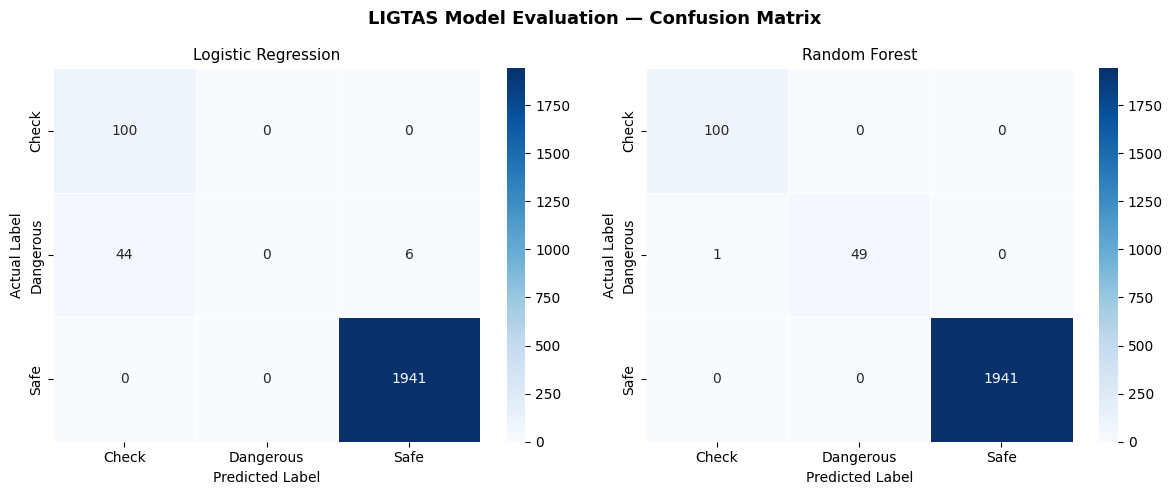

✅ Confusion matrix saved as confusion_matrix.png


In [231]:
# CELL 13 — Confusion Matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LIGTAS Model Evaluation — Confusion Matrix', fontsize=13, fontweight='bold')

models_info = [
    ("Logistic Regression", lr_model),
    ("Random Forest",        rf_model)
]

for ax, (title, model) in zip(axes, models_info):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Check', 'Dangerous', 'Safe'],
        yticklabels=['Check', 'Dangerous', 'Safe'],
        linewidths=0.5
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")

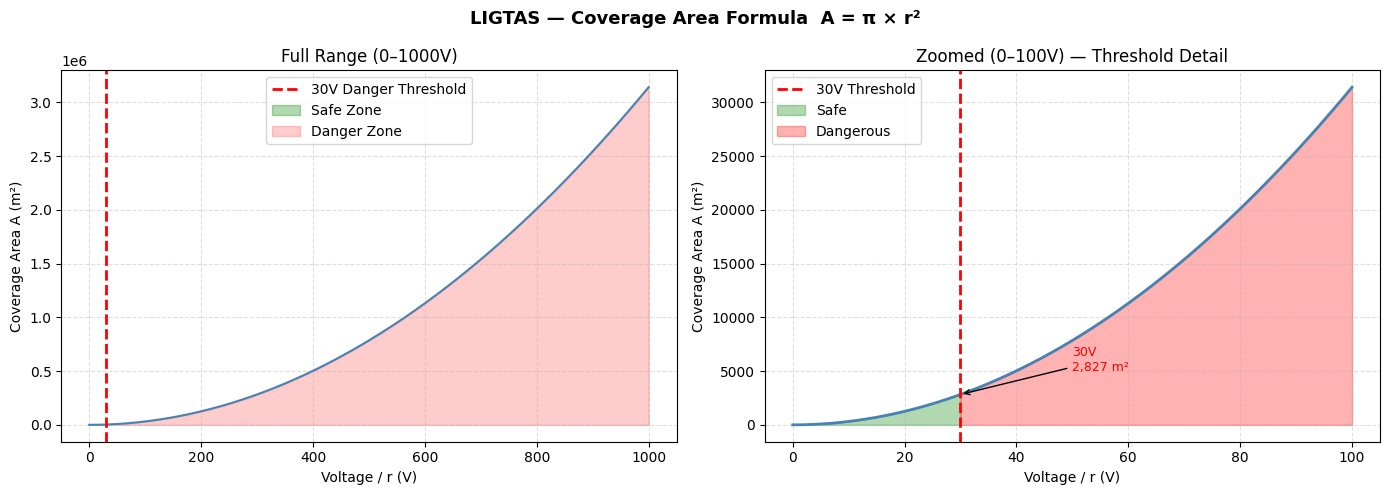

✅ Coverage curve saved as coverage_area_curve.png


In [232]:
# CELL 14 — Visualize A = π × r² with Safe and Dangerous zones

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LIGTAS — Coverage Area Formula  A = π × r²',
             fontsize=13, fontweight='bold')

# --- Full range 0–1000V ---
axes[0].plot(df['voltage_v'], df['coverage_area_m2'],
             color='steelblue', linewidth=1.5)
axes[0].axvline(x=30, color='red', linestyle='--', linewidth=2,
                label='30V Danger Threshold')
axes[0].fill_between(df['voltage_v'], df['coverage_area_m2'],
                     where=(df['voltage_v'] < 30),
                     color='green', alpha=0.3, label='Safe Zone')
axes[0].fill_between(df['voltage_v'], df['coverage_area_m2'],
                     where=(df['voltage_v'] >= 30),
                     color='red', alpha=0.2, label='Danger Zone')
axes[0].set_title('Full Range (0–1000V)')
axes[0].set_xlabel('Voltage / r (V)')
axes[0].set_ylabel('Coverage Area A (m²)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Zoomed 0–100V to show threshold clearly ---
zoom = df[df['voltage_v'] <= 100]
axes[1].plot(zoom['voltage_v'], zoom['coverage_area_m2'],
             color='steelblue', linewidth=2)
axes[1].axvline(x=30, color='red', linestyle='--', linewidth=2,
                label='30V Threshold')
axes[1].fill_between(zoom['voltage_v'], zoom['coverage_area_m2'],
                     where=(zoom['voltage_v'] < 30),
                     color='green', alpha=0.3, label='Safe')
axes[1].fill_between(zoom['voltage_v'], zoom['coverage_area_m2'],
                     where=(zoom['voltage_v'] >= 30),
                     color='red', alpha=0.3, label='Dangerous')
axes[1].annotate('30V\n2,827 m²', xy=(30, np.pi*30**2),
                 xytext=(50, 5000),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, color='red')
axes[1].set_title('Zoomed (0–100V) — Threshold Detail')
axes[1].set_xlabel('Voltage / r (V)')
axes[1].set_ylabel('Coverage Area A (m²)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('coverage_area_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Coverage curve saved as coverage_area_curve.png")

In [233]:
# CELL 15 — Save the trained Random Forest model and scaler

joblib.dump(rf_model, 'ligtas_rf_model.pkl')
joblib.dump(scaler,   'ligtas_scaler.pkl')

print("✅ Files saved in your LIGTAS_Model folder:")
print("   📄 ligtas_rf_model.pkl  — trained model")
print("   📄 ligtas_scaler.pkl    — feature scaler")
print("\nThese files can be loaded anytime without retraining.")

✅ Files saved in your LIGTAS_Model folder:
   📄 ligtas_rf_model.pkl  — trained model
   📄 ligtas_scaler.pkl    — feature scaler

These files can be loaded anytime without retraining.


In [234]:
# CELL 16 — Real-time prediction function (simulates ESP32 input)

def ligtas_predict(voltage_value):
    """
    Given a voltage reading from ZMPT101B sensor,
    calculate coverage area and classify as Safe or Dangerous.
    """
    # Step 1: Apply A = π × r²
    r    = voltage_value
    area = np.pi * (r ** 2)

    # Step 2: Scale
    input_scaled = scaler.transform([[voltage_value, area]])

    # Step 3: Predict
    pred   = rf_model.predict(input_scaled)[0]
    status = "🔴 DANGEROUS — Electrical Leakage Detected!" if pred == 1 else "🟢 SAFE — No Electrical Leakage"

    print(f"  ┌─────────────────────────────────────────")
    print(f"  │  Voltage Input    : {voltage_value} V")
    print(f"  │  Formula          : A = π × {voltage_value}²")
    print(f"  │  Coverage Area    : {area:,.4f} m²")
    print(f"  │  Classification   : {status}")
    print(f"  └─────────────────────────────────────────")

# --- Run test predictions ---
print("=" * 50)
print("  LIGTAS — Voltage Prediction Test")
print("=" * 50)

test_cases = [0.0, 10.0, 29.9, 30.0, 50.0, 110.0, 220.0, 440.0, 1000.0]
for v in test_cases:
    ligtas_predict(v)

  LIGTAS — Voltage Prediction Test
  ┌─────────────────────────────────────────
  │  Voltage Input    : 0.0 V
  │  Formula          : A = π × 0.0²
  │  Coverage Area    : 0.0000 m²
  │  Classification   : 🟢 SAFE — No Electrical Leakage
  └─────────────────────────────────────────
  ┌─────────────────────────────────────────
  │  Voltage Input    : 10.0 V
  │  Formula          : A = π × 10.0²
  │  Coverage Area    : 314.1593 m²
  │  Classification   : 🔴 DANGEROUS — Electrical Leakage Detected!
  └─────────────────────────────────────────
  ┌─────────────────────────────────────────
  │  Voltage Input    : 29.9 V
  │  Formula          : A = π × 29.9²
  │  Coverage Area    : 2,808.6152 m²
  │  Classification   : 🔴 DANGEROUS — Electrical Leakage Detected!
  └─────────────────────────────────────────
  ┌─────────────────────────────────────────
  │  Voltage Input    : 30.0 V
  │  Formula          : A = π × 30.0²
  │  Coverage Area    : 2,827.4334 m²
  │  Classification   : 🟢 SAFE — No Elect

c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib

In [235]:
# CELL 17 — Load saved model without retraining
# Use this in future sessions instead of retraining from scratch

loaded_model  = joblib.load('ligtas_rf_model.pkl')
loaded_scaler = joblib.load('ligtas_scaler.pkl')

print("✅ Model and scaler loaded from files!")

# Quick test
test_v    = 35.0
test_area = np.pi * (test_v ** 2)
test_input = loaded_scaler.transform([[test_v, test_area]])
result     = loaded_model.predict(test_input)[0]

print(f"\nQuick test — Voltage: {test_v}V")
print(f"Result: {'🔴 DANGEROUS' if result == 1 else '🟢 SAFE'}")

✅ Model and scaler loaded from files!

Quick test — Voltage: 35.0V
Result: 🟢 SAFE


c:\Users\Darwin Litiatco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [236]:
import pandas as pd

# Read CSV file
df = pd.read_csv("ligtas_voltage_dataset.csv", header=None, names=["Value", "Count", "Status"])

# Display like Excel
df

,,,,,Value,Count,Status
voltage_v,coverage_area_m2,radius_m,voltage_class,danger_score,risk_flag,label,status
0.0,31415.93,100.0,0,0.0,SAFE,0,Safe
0.01,30796.91,99.0099,0,0.0009,SAFE,0,Safe
0.02,30196.01,98.0392,0,0.0018,SAFE,0,Safe
0.03,29612.52,97.0874,0,0.0027,SAFE,0,Safe
...,...,...,...,...,...,...,...
999.6,0.03,0.0999,4,970.9013,DANGER,2,Dangerous
999.7,0.03,0.0999,4,970.9984,DANGER,2,Dangerous
999.8,0.03,0.0999,4,971.0956,DANGER,2,Dangerous
999.9,0.03,0.0999,4,971.1927,DANGER,2,Dangerous


In [237]:
# CELL 18 — Load existing model and export to Arduino C++
import joblib, numpy as np
from micromlgen import port

# Load your already-trained model and scaler
rf_model = joblib.load('ligtas_rf_model.pkl')
scaler   = joblib.load('ligtas_scaler.pkl')

# Export model to C++ header
with open("ligtas_model.h", "w") as f:
    f.write(port(rf_model))
print("✅ ligtas_model.h created!")

# Print scaler values to copy into ligtas_ml.h
print("\n=== COPY THESE INTO ligtas_ml.h ===")
print(f"const float SCALER_MEAN[2]  = {{{scaler.mean_[0]:.6f}f, {scaler.mean_[1]:.6f}f}};")
print(f"const float SCALER_SCALE[2] = {{{scaler.scale_[0]:.6f}f, {scaler.scale_[1]:.6f}f}};")

✅ ligtas_model.h created!

=== COPY THESE INTO ligtas_ml.h ===
const float SCALER_MEAN[2]  = {477.043574f, 996524.190611f};
const float SCALER_SCALE[2] = {299.387592f, 938162.997044f};
